# 01 — Dataset exploration

The CWRU bearing dataset: what is in it, how the files differ, and why we
resample everything to 12 kHz. Run `python -m preprocessing.download_cwru --all`
first.

In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd().parent))   # run from notebooks/
%matplotlib inline

In [2]:
from preprocessing.cwru_manifest import select_records
records = select_records()
print(len(records), "records")
for r in records[:5]:
    print(r.file_id, r.label(), r.load_hp, "hp", r.sampling_rate, "Hz")

64 records
97 Normal 0 hp 48000 Hz
98 Normal 1 hp 48000 Hz
99 Normal 2 hp 48000 Hz
100 Normal 3 hp 48000 Hz
105 IR007 0 hp 12000 Hz


The Normal recordings are natively 48 kHz while the fault files are 12 kHz, so the loader resamples before anything else touches the signal.

In [3]:
from preprocessing.loader import load_signal
normal = load_signal([r for r in records if r.fault_type == "Normal"][0])
fault  = load_signal([r for r in records if r.fault_type != "Normal"][0])
for s in (normal, fault):
    print(f"{s.record_id:6s} {s.label:10s} {len(s.signal):7d} samples @ {s.sampling_rate} Hz")

97     Normal       60985 samples @ 12000 Hz
105    IR007       121265 samples @ 12000 Hz


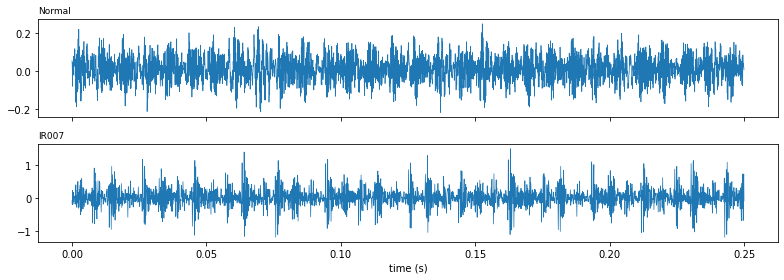

In [4]:
import matplotlib.pyplot as plt, numpy as np
fig, axes = plt.subplots(2, 1, figsize=(11, 4), sharex=True)
for ax, s in zip(axes, (normal, fault), strict=True):
    t = np.arange(3000) / s.sampling_rate
    ax.plot(t, s.signal[:3000], lw=.7); ax.set_title(s.label, loc="left", fontsize=9)
axes[-1].set_xlabel("time (s)"); plt.tight_layout()

The full report and figures come from the module:

In [5]:
!cd .. && PYTHONPATH=. python -m preprocessing.explore

DATASET EXPLORATION -- STEP 1
Dataset               : cwru (DE channel)
Records loaded        : 64 (0 unreadable)
Classes (16)          : B007, B014, B021, B028, IR007, IR014, IR021, IR028, Normal, OR007@12, OR007@3, OR007@6, OR014@6, OR021@12, OR021@3, OR021@6
Target sampling rate  : 12000 Hz (normal baseline natively 48 kHz, resampled)
Signal length (samples): min 60985, max 122917, mean 120908
Total signal duration : 644.8 s

class         records   seconds       rms  kurtosis    crest
--------------------------------------------------------------
B007                4      40.6    0.1448      2.92     4.47
B014                4      40.7    0.1427     12.80    13.03
B021                4      40.7    0.1225      6.09     8.64
B028                4      40.3    2.0994      3.86     5.29
IR007               4      40.7    0.2994      5.45     5.54
IR014               4      40.6    0.1768     20.97    11.43
IR021               4      40.6    0.4762      7.88     7.75
IR028           

Figures written to /home/ubuntu/repos/vibration-ssl-pdm/results/figures
